<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/ANN_CarPrice_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/CarPrice_dataset.csv")
df.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [6]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


<Axes: >

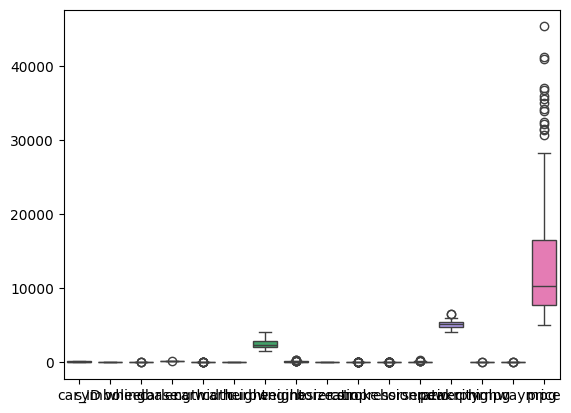

In [8]:
import seaborn as sns
sns.boxplot(df)

In [10]:
for col in df.select_dtypes(include = ['number']).columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]

<Axes: >

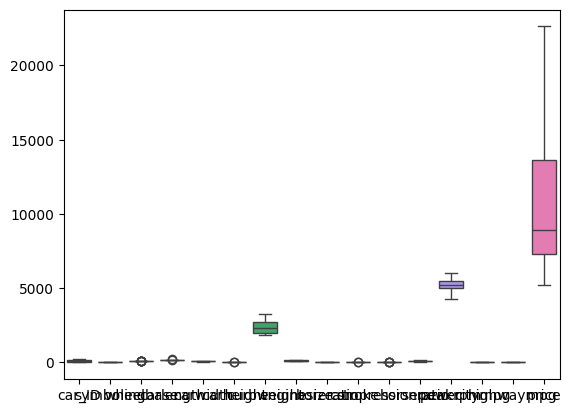

In [11]:
sns.boxplot(df)

In [13]:
x = df.drop(columns = 'price')
y = df['price']

x

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,198,-1,volvo 245,gas,std,four,wagon,rwd,front,104.3,...,four,141,mpfi,3.78,3.15,9.5,114,5400,24,28
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

#identify categorical and numerical columns
categorical_cols=x.select_dtypes(include=['object']).columns.tolist()
numerical_cols=x.select_dtypes(include=['int64','float64']).columns.tolist()

#define preprocessing steps
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('car',OneHotEncoder(handle_unknown='ignore'),categorical_cols)

    ]
)

#apply preprocessing steps
x_processed=preprocessor.fit_transform(x)

#split the data using processed data
x_train,x_test,y_train,y_test=train_test_split(x_processed,y,test_size=0.2,random_state=42)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#define the model
model = Sequential([
    Dense(512, activation = 'relu', input_shape = (x_train.shape[1],)),
    Dense(256, activation = 'relu'),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(12, activation = 'relu'),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,953 (956.85 KB)

 Trainable params: 244,953 (956.85 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer = 'adam', loss = 'mean_absolute_error', metrics = ['mean_absolute_error', 'mean_squared_error'])

In [25]:
history = model.fit(x_train, y_train, epochs = 70, validation_split = 0.2, verbose = 1)

Epoch 1/70
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 11539.7080 - mean_absolute_error: 11539.7080 - mean_squared_error: 151942368.0000 - val_loss: 10553.4209 - val_mean_absolute_error: 10553.4209 - val_mean_squared_error: 135307424.0000
Epoch 2/70
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 11362.9102 - mean_absolute_error: 11362.9102 - mean_squared_error: 148829808.0000 - val_loss: 10552.5830 - val_mean_absolute_error: 10552.5830 - val_mean_squared_error: 135289728.0000
Epoch 3/70
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 11396.5547 - mean_absolute_error: 11396.5547 - mean_squared_error: 149662944.0000 - val_loss: 10551.1035 - val_mean_absolute_error: 10551.1035 - val_mean_squared_error: 135257696.0000
Epoch 4/70
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 11267.5078 - mean_absolute_error: 11267.5078 - mean_squared_error: 147559632.0000 - val_loss: 10548.4404 - val_mean_absolute_error: 10548.4404 - val_mean_squared_error: 135200000.0000
Epoch 5/70
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

In [26]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae}")
print(f"mean squared error: {mse}")
print(f"r2 score: {r2}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
mean absolute error: 1532.6848828125
mean squared error: 3494178.3953250884
r2 score: 0.7633109127390375


In [27]:
#example new data
new_data=x.iloc[[0]]
new_data_precessed=preprocessor.transform(new_data)

predicted_price=model.predict(new_data_precessed)
print('Predicted Price:',predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted Price: 16293.992
